1. Improve the model by using interpolation smoothing with the "Stupid Backoff" method (Brants et al., 2007).

    Two links that i think we can reference:

    [Large Language Models in Machine Translation](https://aclanthology.org/D07-1090.pdf)

    [N-gram Language Models (Speech and Language Processing Book from Stanford)](https://web.stanford.edu/~jurafsky/slp3/3.pdf)

2. Compare with the results from In Class Exercise.

3. Use the newly built model to generate the next words for a given word sequence.

4. Combine with a function that calculates the distance between words to predict the correct word for a misspelled word position. (from difflib import get_close_matches)

# Extracting txt file

Notes on the url link

Our drive links have the format like this: "https://drive.google.com/file/d/extracted_id/view?usp=sharing"

Keep that extracted id and paste in this link: "https://docs.google.com/uc?export=download&id=extracted_id"

In [1]:
import requests

txt_url = "https://docs.google.com/uc?export=download&id=14jsTimd626t7Vm9b-Bsvv6jq4UxbNVHN"
response = requests.get(txt_url)
txt_content = response.text

print(txt_content[:1000])

Thank you so much, Chris. And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful. I have been blown away by this conference, and I want to thank all of you for the many nice comments about what I had to say the other night. And I say that sincerely, partly because (Mock sob) I need that. (Laughter) Put yourselves in my position. (Laughter) I flew on Air Force Two for eight years. (Laughter) Now I have to take off my shoes or boots to get on an airplane! (Laughter) (Applause) I'll tell you one quick story to illustrate what that's been like for me. (Laughter) It's a true story — every bit of this is true. Soon after Tipper and I left the — (Mock sob) White House — (Laughter) we were driving from our home in Nashville to a little farm we have 50 miles east of Nashville. Driving ourselves. (Laughter) I know it sounds like a little thing to you, but — (Laughter) I looked in the rear-view mirror and all of a sudden it just hit me. There was 

# Building language model using "Stupid Backoff" smoothing method

## Building language models with 1-gram, 2-gram, and 3-gram

In [2]:
from collections import Counter
import nltk
from nltk import word_tokenize, sent_tokenize
from nltk import ngrams
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
def build_LMs(string):
  sentences = sent_tokenize(string)
  num_sentence = len(sentences)

  LM_1gram = Counter()
  LM_2gram = Counter()
  LM_3gram = Counter()
  LM_4gram = Counter()
  LM_5gram = Counter()

  for sentence in sentences:
    words = word_tokenize(sentence.lower())

    # Build 1-gram
    LM_1gram.update(words)

    # Build 2-gram
    begin_bigram = [("<s>", words[0])]
    LM_2gram.update(begin_bigram)
    bigrams = list(ngrams(words, n = 2))
    LM_2gram.update(bigrams)

    # Build 3-gram
    begin_trigram = [("<s>", "<s>", words[0])]
    LM_3gram.update(begin_trigram)
    trigrams = list(ngrams(words, n = 3))
    LM_3gram.update(trigrams)

    # Build 4-gram
    begin_quadgram = [("<s>", "<s>", "<s>", words[0])]
    LM_4gram.update(begin_quadgram)
    quadgrams = list(ngrams(words, n = 4))
    LM_4gram.update(quadgrams)

    # Build 4-gram
    begin_pentagram = [("<s>", "<s>", "<s>", "<s>", words[0])]
    LM_5gram.update(begin_pentagram)
    pentagram = list(ngrams(words, n = 5))
    LM_5gram.update(pentagram)

  return num_sentence, LM_1gram, LM_2gram, LM_3gram, LM_4gram,  LM_5gram


In [4]:
num_sentence, LM_1gram, LM_2gram, LM_3gram, LM_4gram,  LM_5gram = build_LMs(txt_content)

## "Stupid Backoff" smoothing method

In [5]:
# Hyper-parameter
lambda_1 = 0.4
lambda_2 = 0.4
lambda_3 = 0.4
lambda_4 = 0.4

### 1-gram

In [6]:
def calculate_P_1gram(word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_1gram[word_i] + 1) / (len(LM_1gram) + LM_1gram.total())


  ########## Back off method ##########

  # Check count
  if LM_1gram[word_i] != 0:
    return LM_1gram[word_i] / LM_1gram.total()
  else:
    return 1 / LM_1gram.total() # I assigned this to prevent unseen unigram

### 2-gram

In [7]:
def calculate_P_2gram(word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_2gram[(word_i1, word_i)] + 1) / (LM_1gram[word_i1] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_2gram[(word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>":
      return LM_2gram[(word_i1, word_i)] / num_sentence
    else:
      return LM_2gram[(word_i1, word_i)] / LM_1gram[word_i1]
  else:
    return lambda_1 * calculate_P_1gram(word_i)

### 3-gram

In [8]:
def calculate_P_3gram(word_i2, word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_3gram[(word_i2, word_i1, word_i)] + 1) / (LM_2gram[(word_i2, word_i1)] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_3gram[(word_i2, word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>" and word_i2 == "<s>":
      return LM_3gram[(word_i2, word_i1, word_i)] / num_sentence
    else:
      return LM_3gram[(word_i2, word_i1, word_i)] / LM_2gram[(word_i2, word_i1)]
  else:
    return lambda_2 * calculate_P_2gram(word_i1, word_i)

### 4-gram

In [9]:
def calculate_P_4gram(word_i3, word_i2, word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_4gram[(word_i3, word_i2, word_i1, word_i)] + 1) / (LM_3gram[(word_i3, word_i2, word_i1)] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_4gram[(word_i3, word_i2, word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>" and word_i2 == "<s>" and word_i3 == "<s>":
      return LM_4gram[(word_i3, word_i2, word_i1, word_i)] / num_sentence
    else:
      return LM_4gram[(word_i3, word_i2, word_i1, word_i)] / LM_3gram[(word_i3, word_i2, word_i1)]
  else:
    return lambda_3 * calculate_P_3gram(word_i2, word_i1, word_i)

### 5-gram

In [10]:
def calculate_P_5gram(word_i4, word_i3, word_i2, word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_5gram[(word_i4, word_i3, word_i2, word_i1, word_i)] + 1) / (LM_4gram[(word_i4, word_i3, word_i2, word_i1)] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_5gram[(word_i4, word_i3, word_i2, word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>" and word_i2 == "<s>" and word_i3 == "<s>" and word_i4 == "<s>":
      return LM_5gram[(word_i4, word_i3, word_i2, word_i1, word_i)] / num_sentence
    else:
      return LM_5gram[(word_i4, word_i3, word_i2, word_i1, word_i)] / LM_4gram[(word_i4, word_i3, word_i2, word_i1)]
  else:
    return lambda_4 * calculate_P_4gram(word_i3, word_i2, word_i1, word_i)

# Generating the next words for a given word sequence.

In [11]:
def get_potential_next_words(word_i4, word_i3, word_i2, word_i1):
  potential_next_words = []

  # Pentagram
  for (w4, w3, w2, w1, w0) in LM_5gram.keys():
    if (w4, w3, w2, w1) == (word_i4, word_i3, word_i2, word_i1):
      potential_next_words.append(w0)

  # Quadgram
  if not potential_next_words:
    for (w3, w2, w1, w0) in LM_4gram.keys():
      if (w3, w2, w1) == (word_i3, word_i2, word_i1):
        potential_next_words.append(w0)

  # Trigram
  if not potential_next_words:
    for (w2, w1, w0) in LM_3gram.keys():
      if (w2, w1) == (word_i2, word_i1):
        potential_next_words.append(w0)

  # Bigram if not trigram
  if not potential_next_words:
    for (w1, w0) in LM_2gram.keys():
      if w1 == word_i1:
        potential_next_words.append(w0)

  # Unigram
  if not potential_next_words:
    potential_next_words = list(LM_1gram.keys())

  return potential_next_words

In [12]:
import random
import string

def gen_word(word_i4, word_i3, word_i2, word_i1, top_k):
  ### Switch to next sentence ###
  if word_i1 == ".":
    return "<s>"

  ### Normal flow ###

  potential_next_words = get_potential_next_words(word_i4, word_i3, word_i2, word_i1)

  words_probability = []

  for word in potential_next_words:
    words_probability.append((word, calculate_P_5gram(word_i4, word_i3, word_i2, word_i1, word)))

  words_probability.sort(key = lambda x: x[1], reverse = True)
  top_k_words = [word for word in words_probability[:top_k]]

  if top_k_words:
    word = random.choice(top_k_words)[0]
    if word in string.punctuation:
      word = random.choice(top_k_words)[0]
    return word
  else:
    return "."

In [16]:
def gen_words(given_sentence, top_k = 5, max_len = 50):
  tokens = word_tokenize(given_sentence.lower())

  word_i4, word_i3, word_i2, word_i1 = None, None, None, None
  if len(tokens) >= 4:
    word_i4, word_i3, word_i2, word_i1 = tokens[-4], tokens[-3], tokens[-2], tokens[-1]
  elif len(tokens) == 3:
    word_i4, word_i3, word_i2, word_i1 = "<s>", tokens[-3], tokens[-2], tokens[-1]
  elif len(tokens) == 2:
    word_i4, word_i3, word_i2, word_i1 = "<s>", "<s>", tokens[-2], tokens[-1]
  elif len(tokens) == 1:
    word_i4, word_i3, word_i2, word_i1 = "<s>", "<s>", "<s>", tokens[-1]
  else:
    word_i2, word_i1 = "<s>", "<s>", "<s>", "<s>"

  predicted_tokens = []
  for i in range(max_len):
    predicted_tokens.append(gen_word(word_i4, word_i3, word_i2, word_i1, top_k))
    word_i4 = word_i3
    word_i3 = word_i2
    word_i2 = word_i1
    word_i1 = predicted_tokens[-1]

  return " ".join(predicted_tokens)

In [18]:
given_sentence = "Hey,"
print(given_sentence + " " + gen_words(given_sentence, top_k = 1, max_len = 40))

given_sentence = "I have a"
print(given_sentence + " " + gen_words(given_sentence, top_k = 2, max_len = 40))

given_sentence = "This is a very good"
print(given_sentence + " " + gen_words(given_sentence, top_k = 3, max_len = 40))

given_sentence = "I'm very proud of myself"
print(given_sentence + " " + gen_words(given_sentence, top_k = 4, max_len = 40))

given_sentence = "Thank you very"
print(given_sentence + " " + gen_words(given_sentence, top_k = 5, max_len = 40))

Hey, i 'm here to tell you that the way our textbooks — particularly mass-adopted textbooks — teach math reasoning and patient problem solving , it 's functionally equivalent to turning on `` two and a half years ago , when
I have a dream '' speech . <s> and the reason is that they 're not going to be able to make the right choice , probably , to the biggest threat to sharks worldwide — the finning of sharks . <s> so
This is a very good example of design . <s> so , we 've got the best school award for three years successively . <s> so i think that we 're going to be able to see it this way , day one , which
I'm very proud of myself . <s> and the reason for this shape is that at the end , i would like it if butterflies could talk , but i want other people and other young girls that have experienced what i 've experienced to
Thank you very , very much about the way we link thinking and doing . <s> i think we can make progress . <s> i was going to say holding my first abacus , but actuall

## Some thought
As i see, giving k = 5 is quite okay:v If we increase k, the sentences seems irrelevant, and the structure weired also.

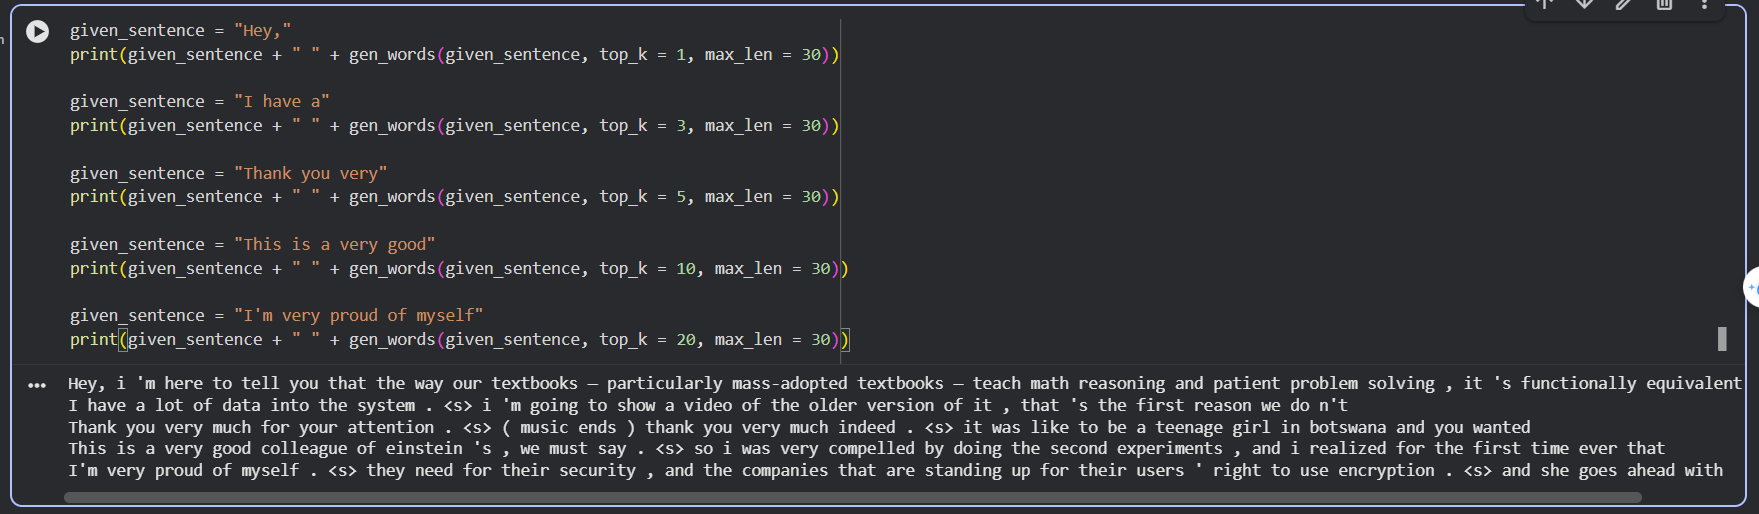